<a href="https://colab.research.google.com/github/rahafabumwise/IEEE-AI-Modeling-Hackathon-2.0-Stage-1-Challenge/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Libraries

In [7]:
from google.colab import drive
import os
import pandas as pd
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
from xgboost import XGBRegressor

## 1. Setup

In [8]:
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
path = "/content/drive/MyDrive/datasets/ieee-ai-modeling-hackathon2-stage-1-challenge"

In [33]:
train = pd.read_csv(path+"/train.csv")
test = pd.read_csv(path+"/test.csv")

print("shape train:", train.shape)
print("shape test:", test.shape)
print()
print(train.info())

shape train: (24000, 44)
shape test: (16000, 43)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 44 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   24000 non-null  int64  
 1   sensor_20            24000 non-null  float64
 2   humidity             22106 non-null  float64
 3   sensor_22            24000 non-null  float64
 4   sensor_19            24000 non-null  float64
 5   sensor_01            24000 non-null  float64
 6   vibration_rms        22848 non-null  float64
 7   sensor_24            24000 non-null  float64
 8   sensor_07            24000 non-null  float64
 9   core_temp            24000 non-null  float64
 10  sensor_17            22087 non-null  float64
 11  sensor_15            24000 non-null  float64
 12  sensor_02            24000 non-null  float64
 13  sensor_11            24000 non-null  float64
 14  sensor_14            24000 non-null 

In [34]:
# Keep untouched raw feature tables
X_raw = train.drop(columns=["id", "edi"]).copy()
X_test_raw = test.drop(columns=["id"]).copy()

# Original target
y_raw = train["edi"].copy()

# Model will learn the logarithmic target
y_log = np.log1p(y_raw)

test_ids = test["id"].copy()

print("X_raw:", X_raw.shape)
print("X_test_raw:", X_test_raw.shape)
print("y:", y_log.shape)

X_raw: (24000, 42)
X_test_raw: (16000, 42)
y: (24000,)


## 2. EDA (Exploratory Data Analysis)

In [ ]:
print("duplicate rows in train:", train.duplicated().sum())
print("duplicate ids in train:", train['id'].duplicated().sum())
print("duplicate ids in test:", test['id'].duplicated().sum())
print("overlap between train and test ids:", len(set(train['id']) & set(test['id'])))

duplicate rows in train: 0
duplicate ids in train: 0
duplicate ids in test: 0
overlap between train and test ids: 0


--- edi describe ---
count    24000.000000
mean        79.448278
std         82.364619
min          3.362100
25%         23.915800
50%         51.075700
75%        105.025925
max        796.341500
Name: edi, dtype: float64


<Axes: >

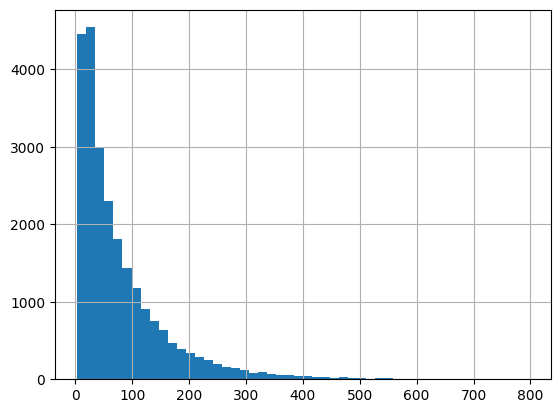

In [ ]:
print("--- edi describe ---")
print(train['edi'].describe())
train['edi'].hist(bins=50)

In [60]:
print("--- missing values in train ---")
missing = train.isna().sum()
print(missing[missing > 0])

--- missing values in train ---
humidity               1894
vibration_rms          1152
sensor_17              1913
sensor_05               910
hours_since_service     869
coolant_flow           1392
dtype: int64


In [61]:
print("--- missing values in test ---")
missing = test.isna().sum()
print(missing[missing > 0])

--- missing values in test ---
humidity               1287
vibration_rms           732
sensor_17              1218
sensor_05               634
hours_since_service     570
coolant_flow            949
dtype: int64


In [62]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.drop(['id', 'edi'])
corr_with_target = train[numeric_cols].corrwith(train['edi']).sort_values(ascending=False)
print("--- top correlations with edi ---")
print(corr_with_target.head(10))
print("\n--- lowest correlations ---")
print(corr_with_target.tail(10))

--- top correlations with edi ---
core_temp              0.482292
sensor_25              0.479978
asset_age              0.451897
delta_ambient          0.432663
harmonic_thd           0.256037
load_factor            0.226177
vibration_rms          0.210374
sensor_01              0.204947
hours_since_service    0.199539
sensor_04              0.199257
dtype: float64

--- lowest correlations ---
sensor_18      -0.004589
sensor_26      -0.007342
sensor_15      -0.008444
sensor_28      -0.095570
grid_freq      -0.101286
line_voltage   -0.104358
sensor_03      -0.194375
sensor_13      -0.250757
sensor_06      -0.350625
sensor_02      -0.547707
dtype: float64


In [63]:
known_cols = ['load_factor','core_temp','vibration_rms','grid_freq','line_voltage',
              'chamber_pressure','coolant_flow','humidity','asset_age','duty_cycle',
              'harmonic_thd','phase_imbalance','hours_since_service','delta_ambient']

print("--- min/max for known physical columns (sanity check) ---")
print(train[known_cols].describe().T[['min', 'max']])

# Physical validity checks
if (train['humidity'] < 0).any() or (train['humidity'] > 100).any():
    print("WARNING: humidity values outside 0-100")
if (train['duty_cycle'] < 0).any() or (train['duty_cycle'] > 1).any():
    print("WARNING: duty_cycle values outside 0-1")

always_positive_cols = ['vibration_rms', 'chamber_pressure', 'coolant_flow',
                         'core_temp', 'line_voltage', 'harmonic_thd',
                         'phase_imbalance', 'asset_age', 'hours_since_service']
for col in always_positive_cols:
    if (train[col] < 0).any():
        print(f"WARNING: negative values found in {col}")

print("all physical range checks passed")

--- min/max for known physical columns (sanity check) ---
                           min         max
load_factor            0.22382    30.10615
core_temp             18.29720   104.53948
vibration_rms          0.05000     5.41932
grid_freq             49.36113    50.38940
line_voltage         376.40042   437.38453
chamber_pressure       0.92435    14.65130
coolant_flow           1.26965    26.91642
humidity               2.00000    99.00000
asset_age              0.10052    21.99907
duty_cycle             0.00844     1.00000
harmonic_thd           0.00252     9.00982
phase_imbalance        0.00004     5.84711
hours_since_service   30.00900  8237.26862
delta_ambient        -11.34942    86.79632
all physical range checks passed


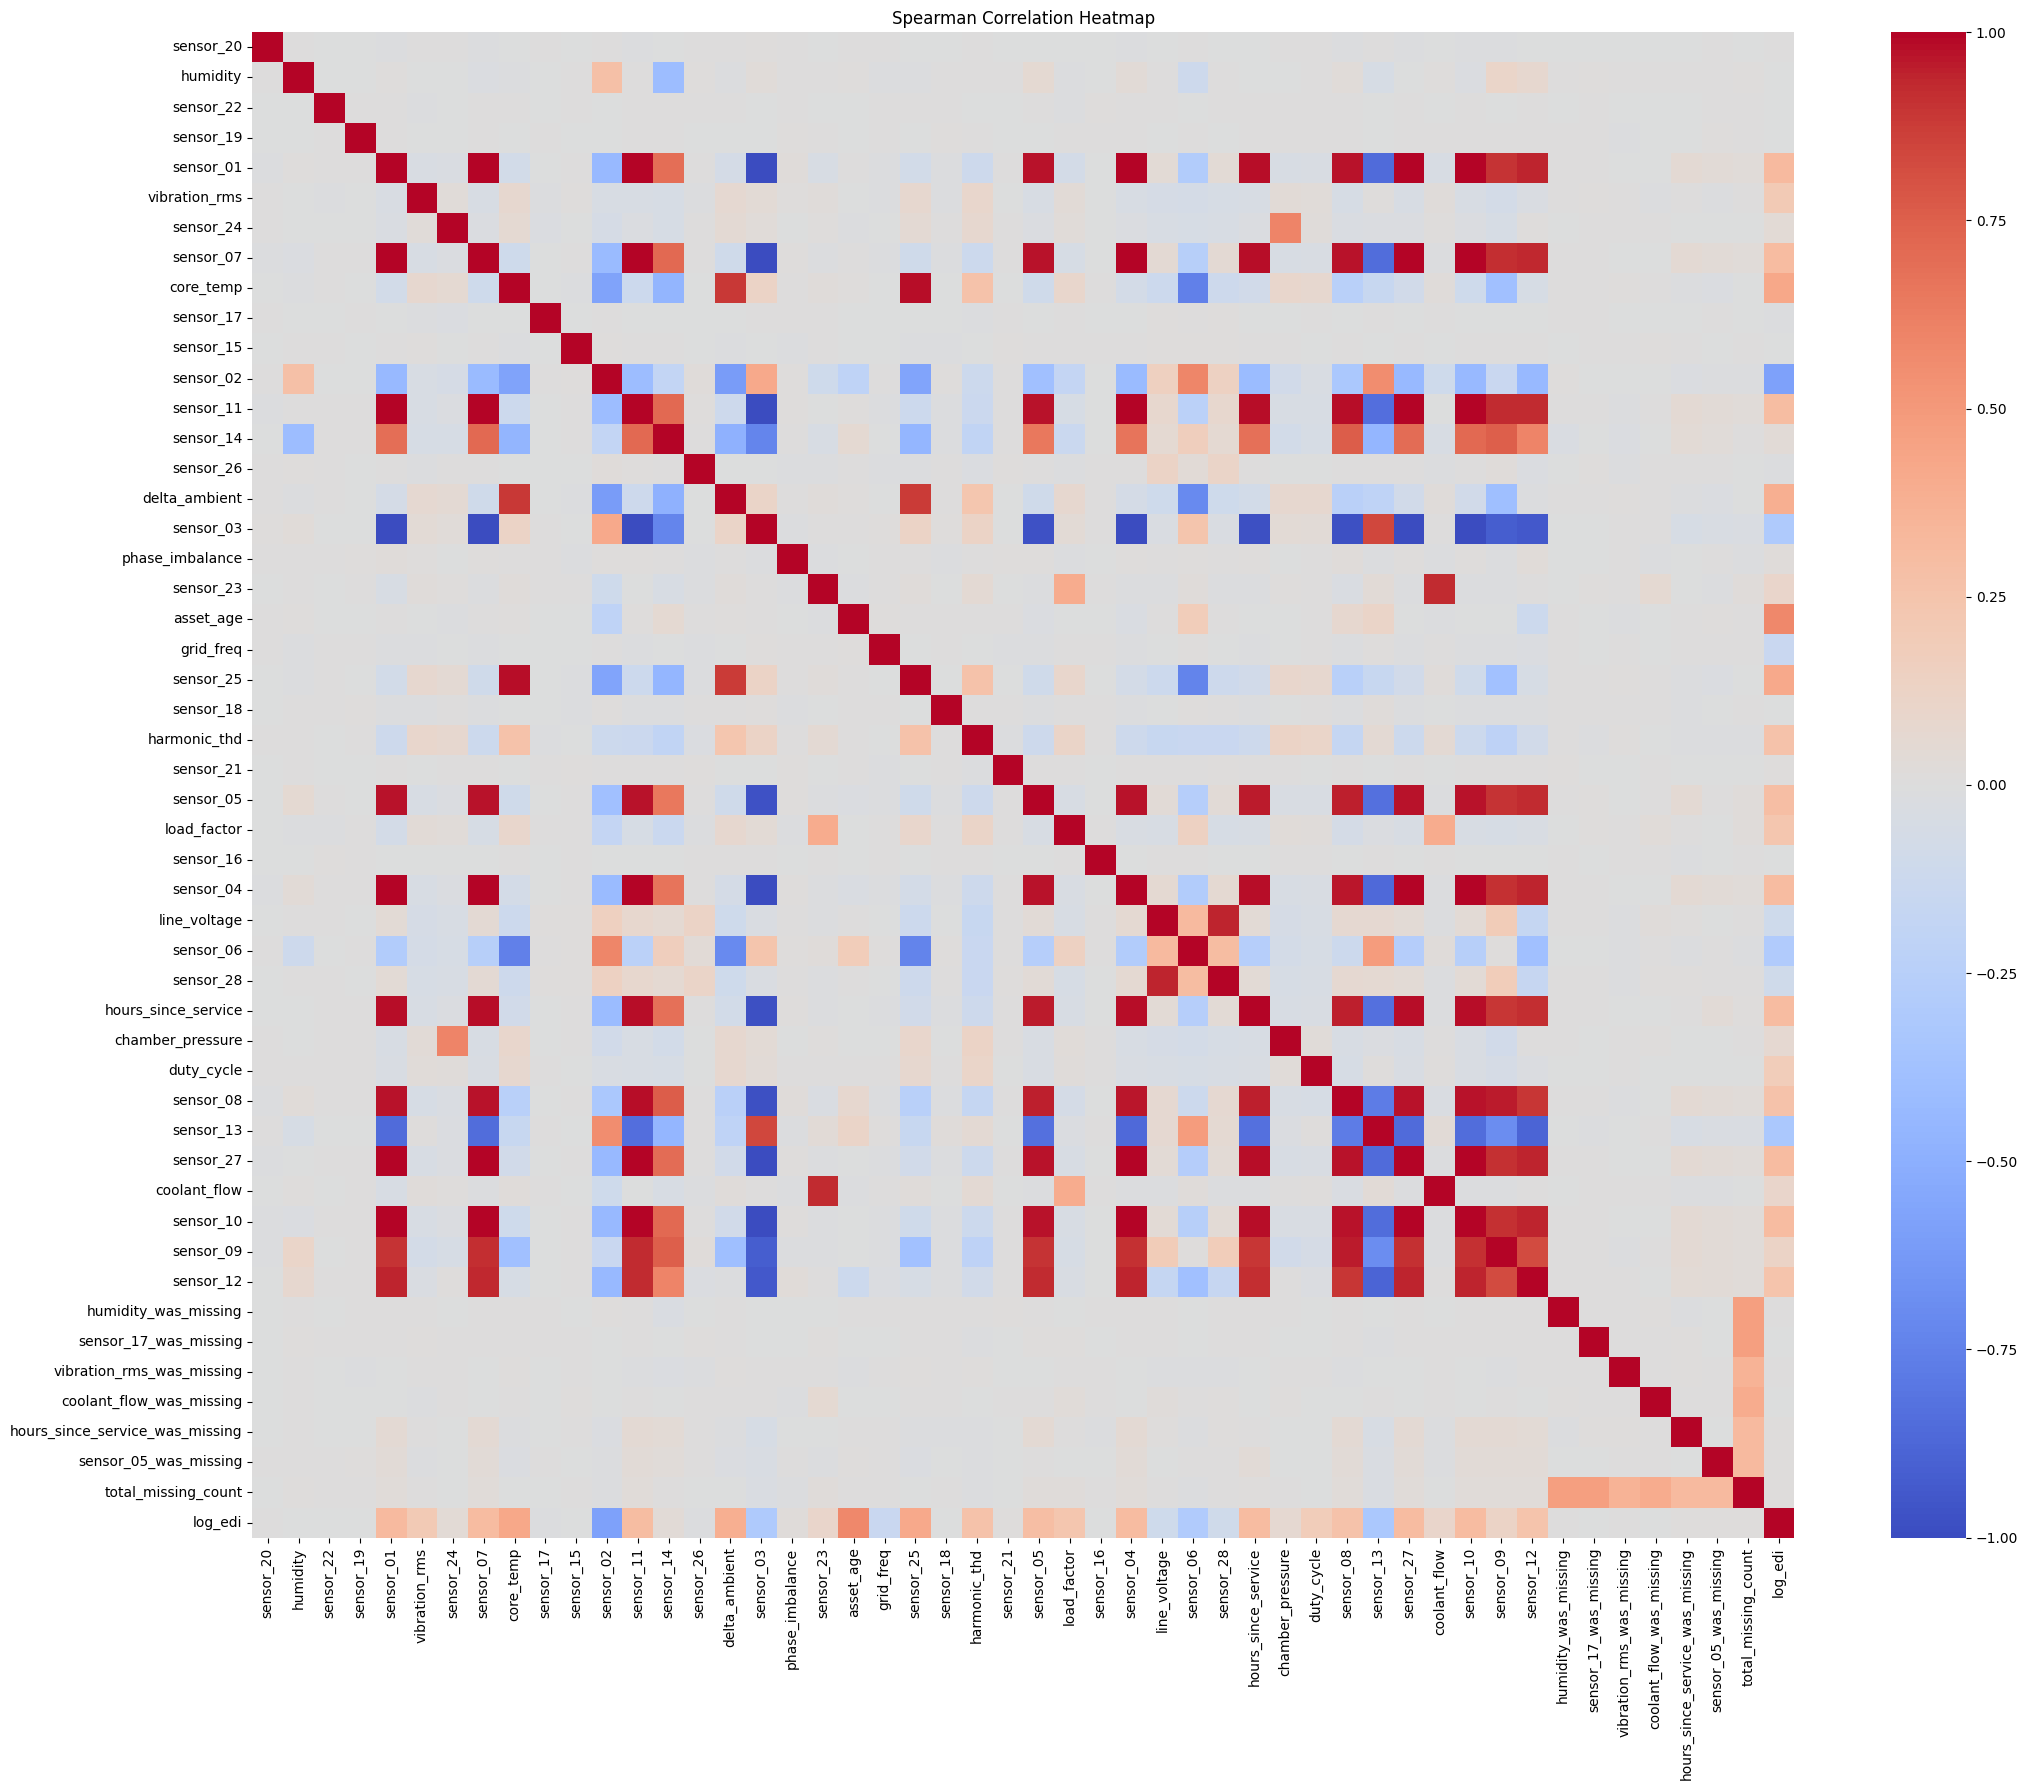

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Create a copy so the original train dataset is not modified
corr_data = train.copy()

# Remove the ID because it is not a physical feature
corr_data = corr_data.drop(columns=["id"], errors="ignore")

# Create a log-transformed target
corr_data["log_edi"] = np.log1p(corr_data["edi"])

# Remove the original edi to avoid displaying both targets
corr_data = corr_data.drop(columns=["edi"])

# Calculate Spearman correlations
corr_matrix = corr_data.corr(method="spearman")

# Draw the heatmap
plt.figure(figsize=(22, 18))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Spearman Correlation Heatmap")
plt.tight_layout()
plt.show()

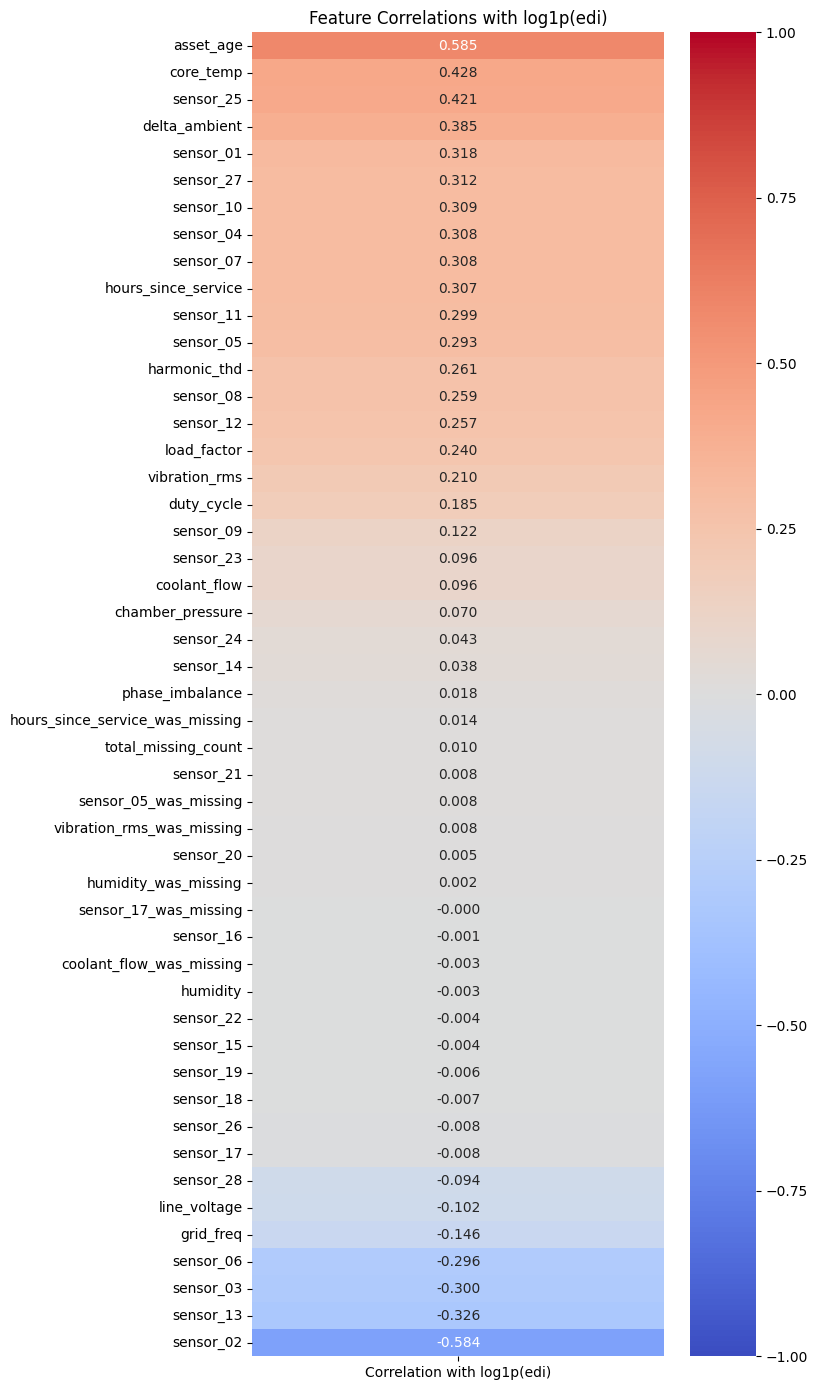

In [22]:
# Correlations with the target
target_corr = (
    corr_matrix["log_edi"]
    .drop("log_edi")
    .sort_values(ascending=False)
)

# Convert the Series into a one-column DataFrame
target_corr_df = target_corr.to_frame(name="Correlation with log1p(edi)")

plt.figure(figsize=(8, 14))

sns.heatmap(
    target_corr_df,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Feature Correlations with log1p(edi)")
plt.tight_layout()
plt.show()

In [23]:
# Correlation matrix containing features only
feature_corr = corr_data.drop(columns=["log_edi"]).corr(method="spearman")

high_corr_pairs = []

columns = feature_corr.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        correlation = feature_corr.iloc[i, j]

        if abs(correlation) >= 0.90:
            high_corr_pairs.append({
                "feature_1": columns[i],
                "feature_2": columns[j],
                "spearman_correlation": correlation
            })

high_corr_pairs_df = pd.DataFrame(high_corr_pairs)

high_corr_pairs_df["absolute_correlation"] = (
    high_corr_pairs_df["spearman_correlation"].abs()
)

high_corr_pairs_df = high_corr_pairs_df.sort_values(
    "absolute_correlation",
    ascending=False
)

print(high_corr_pairs_df.head(30))
print("\nNumber of pairs above 0.90:", len(high_corr_pairs_df))

              feature_1            feature_2  spearman_correlation  \
18            sensor_07            sensor_10              0.999664   
17            sensor_07            sensor_27              0.999511   
61            sensor_27            sensor_10              0.999499   
36            sensor_03            sensor_10             -0.998840   
12            sensor_07            sensor_03             -0.998742   
35            sensor_03            sensor_27             -0.998273   
11            sensor_07            sensor_11              0.997590   
27            sensor_11            sensor_27              0.997428   
28            sensor_11            sensor_10              0.997294   
49            sensor_04            sensor_27              0.997008   
7             sensor_01            sensor_27              0.996973   
0             sensor_01            sensor_07              0.996525   
8             sensor_01            sensor_10              0.996512   
22            sensor

**EDA summary:** shape, duplicates, missing values, correlations, and physical-range checks
all verified clean. No physically invalid values found.

## 3. Missing Value Handling

In [64]:
MISSING_COLS = [
    "humidity",
    "sensor_17",
    "vibration_rms",
    "coolant_flow",
    "hours_since_service",
    "sensor_05"
]


def preprocess_fold(X_train_fold, X_valid_fold):
    """
    Learn preprocessing information only from the training fold.
    Then apply it to both training and validation.
    """

    X_train_fold = X_train_fold.copy()
    X_valid_fold = X_valid_fold.copy()

    # ------------------------------------------
    # 1. Preserve missingness before imputation
    # ------------------------------------------
    for col in MISSING_COLS:
        X_train_fold[f"{col}_was_missing"] = (
            X_train_fold[col].isna().astype(int)
        )

        X_valid_fold[f"{col}_was_missing"] = (
            X_valid_fold[col].isna().astype(int)
        )

    # ------------------------------------------
    # 2. Count missing columns per observation
    # ------------------------------------------
    X_train_fold["total_missing_count"] = (
        X_train_fold[MISSING_COLS].isna().sum(axis=1)
    )

    X_valid_fold["total_missing_count"] = (
        X_valid_fold[MISSING_COLS].isna().sum(axis=1)
    )

    # ------------------------------------------
    # 3. Learn medians from training fold only
    # ------------------------------------------
    fold_medians = {}

    for col in MISSING_COLS:
        median_value = X_train_fold[col].median()
        fold_medians[col] = median_value

        X_train_fold[col] = X_train_fold[col].fillna(
            median_value
        )

        X_valid_fold[col] = X_valid_fold[col].fillna(
            median_value
        )

    return X_train_fold, X_valid_fold, fold_medians

**Missing-value summary:** missing indicators created for all 6 affected columns before
imputation (in case missingness itself carries signal), then median-filled. Missingness pattern
confirmed consistent between train and test.

## 4. Target Transformation

--- edi vs log_edi ---
                edi       log_edi
count  24000.000000  24000.000000
mean      79.448278      3.950546
std       82.364619      0.948804
min        3.362100      1.472954
25%       23.915800      3.215502
50%       51.075700      3.952698
75%      105.025925      4.663684
max      796.341500      6.681283


<Axes: >

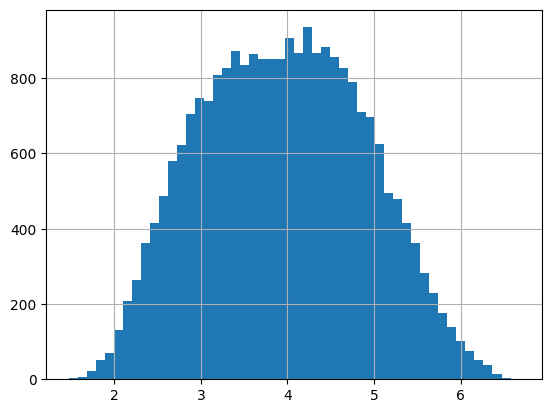

In [65]:
train['log_edi'] = np.log1p(train['edi'])

print("--- edi vs log_edi ---")
print(train[['edi', 'log_edi']].describe())
train['log_edi'].hist(bins=50)  # should look much more symmetric than raw edi

## 5. Feature Engineering

Three additions to the base feature set, each validated via cross-validation during
development (see Experiments Log for the discarded alternatives):
1. **Hidden regime discovery** (KMeans on scaled features) — the data contains 2 physically
   distinct operating regimes.
2. **`stress_index`** and **`load_duty_combo`** — physics-informed interaction features
   (temperature × load × duty cycle). `stress_index` turned out to be the single most important
   diagnostic feature in this whole project (see Section 6).
3. **Ratio features** (`asset_age_div_line_voltage`, `asset_age_div_grid_freq`).

In [66]:
def add_engineered_features(X):
    X = X.copy()

    X["load_duty_combo"] = (
        X["load_factor"] * X["duty_cycle"]
    )

    X["stress_index"] = (
        X["core_temp"]
        * X["load_factor"]
        * X["duty_cycle"]
    )

    return X

#the train–test distribution shift.

In [68]:
import pandas as pd

features = [c for c in train.columns if c not in ["id", "edi", "log_edi"]]

shift_summary = pd.DataFrame({
    "train_mean": train[features].mean(),
    "test_mean": test[features].mean(),
    "train_median": train[features].median(),
    "test_median": test[features].median(),
    "train_missing_%": train[features].isna().mean() * 100,
    "test_missing_%": test[features].isna().mean() * 100
})

shift_summary["mean_difference"] = (
    shift_summary["test_mean"] - shift_summary["train_mean"]
)

shift_summary["relative_mean_change_%"] = (
    shift_summary["mean_difference"]
    / shift_summary["train_mean"].abs()
    * 100
)

shift_summary = shift_summary.sort_values(
    "relative_mean_change_%",
    key=lambda x: x.abs(),
    ascending=False
)

print(shift_summary.head(15))

              train_mean    test_mean  train_median  test_median  \
sensor_16      -0.000853     0.009581      0.001230    -0.002185   
sensor_17      -0.015588     0.037890     -0.015660     0.022840   
sensor_20      -0.002226     0.003433      0.000110     0.003800   
sensor_21      -0.011097     0.011720      0.004790    -0.002630   
sensor_18       0.019383    -0.007767      0.016620    -0.009695   
sensor_15       0.008659    -0.001201     -0.003550    -0.022040   
sensor_22      -0.009921    -0.001388      0.004460     0.007235   
sensor_03     -42.999170   -29.789896      2.433955    12.140180   
sensor_19       0.024104     0.019344      0.025565     0.026185   
sensor_08      25.817979    22.251119     16.570935    13.713100   
sensor_27    7059.740406  6216.127282   3116.830030  2735.967040   
sensor_10     147.590080   131.043136     88.245770    76.335205   
load_factor     6.566271     7.253202      5.915795     6.579580   
sensor_01      41.196646    36.960820     25.224

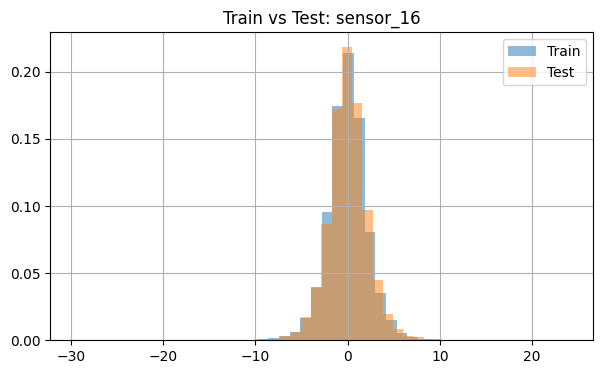

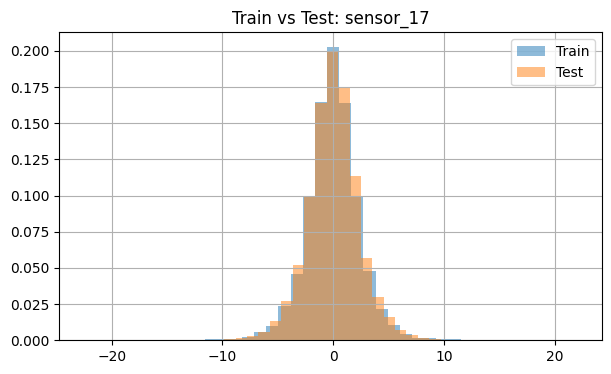

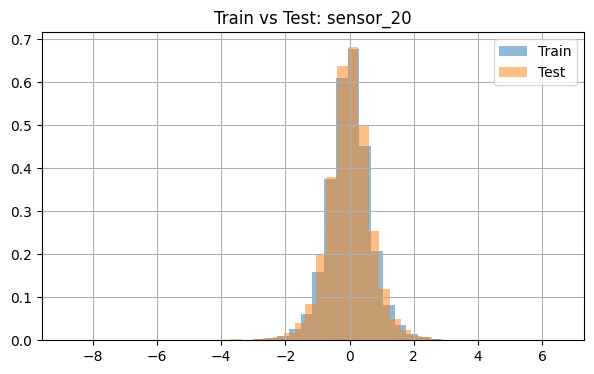

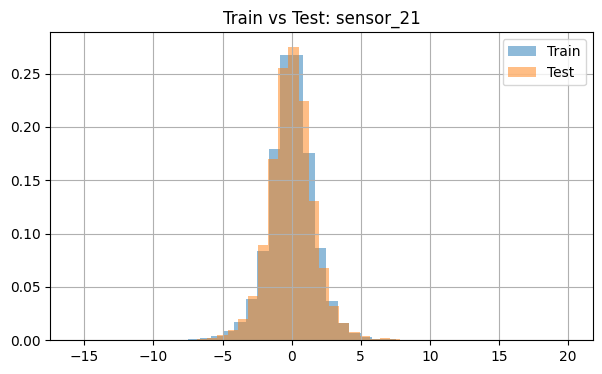

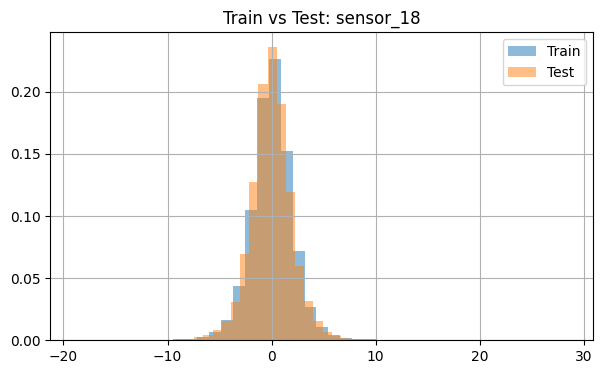

In [69]:
import matplotlib.pyplot as plt

top_shifted = shift_summary.head(5).index

for col in top_shifted:
    plt.figure(figsize=(7, 4))

    train[col].dropna().hist(
        bins=40,
        alpha=0.5,
        density=True,
        label="Train"
    )

    test[col].dropna().hist(
        bins=40,
        alpha=0.5,
        density=True,
        label="Test"
    )

    plt.title(f"Train vs Test: {col}")
    plt.legend()
    plt.show()

In [70]:
from scipy.stats import ks_2samp
import pandas as pd

features = [
    c for c in train.columns
    if c not in ["id", "edi", "log_edi"]
]

shift_results = []

for col in features:
    train_values = train[col].dropna()
    test_values = test[col].dropna()

    ks_stat, p_value = ks_2samp(
        train_values,
        test_values
    )

    shift_results.append({
        "feature": col,
        "ks_stat": ks_stat,
        "p_value": p_value,
        "train_mean": train_values.mean(),
        "test_mean": test_values.mean(),
        "train_median": train_values.median(),
        "test_median": test_values.median(),
        "train_missing_%": train[col].isna().mean() * 100,
        "test_missing_%": test[col].isna().mean() * 100
    })

shift_results = pd.DataFrame(shift_results).sort_values(
    "ks_stat",
    ascending=False
)

print(shift_results.head(15))

          feature   ks_stat        p_value  train_mean   test_mean  \
8       core_temp  0.146000  4.661104e-179   59.229526   62.990345   
21      sensor_25  0.144854  2.980530e-176   29.953079   32.096583   
15  delta_ambient  0.139229  8.350716e-163   38.230592   41.952267   
13      sensor_14  0.131042  3.369093e-144  -34.303976  -36.283095   
30      sensor_06  0.107125   2.169975e-96   33.193240   32.204642   
23   harmonic_thd  0.091854   6.171524e-71    3.205092    3.480921   
20      grid_freq  0.083271   2.342515e-58   49.900486   49.924043   
26    load_factor  0.082083   1.028762e-56    6.566271    7.253202   
1        humidity  0.079465   5.715894e-49   47.733197   50.443544   
40      sensor_09  0.075188   1.208656e-47  107.857737  104.272153   
11      sensor_02  0.074146   2.414889e-46    9.795195    8.969197   
35      sensor_08  0.056417   5.327503e-27   25.817979   22.251119   
29   line_voltage  0.056125   1.001602e-26  407.876414  407.068295   
31      sensor_28  0

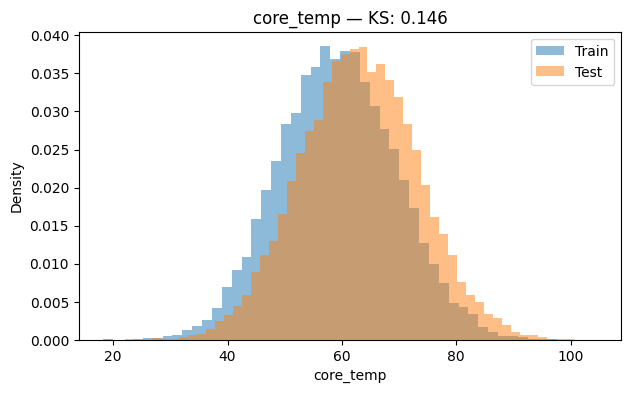

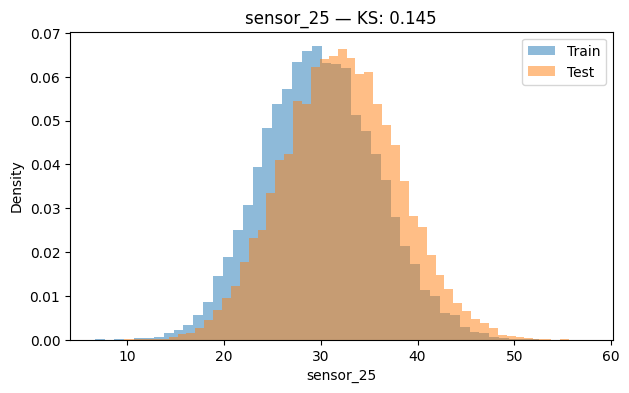

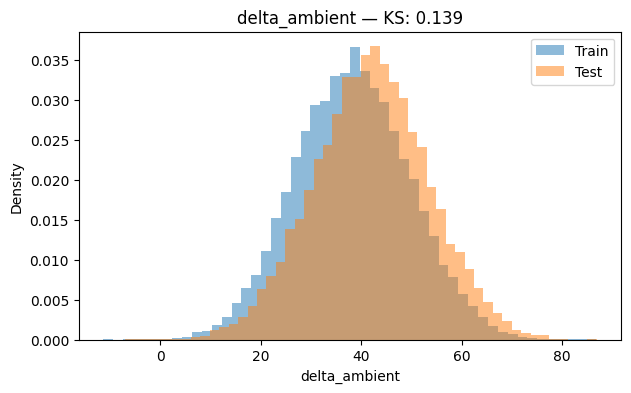

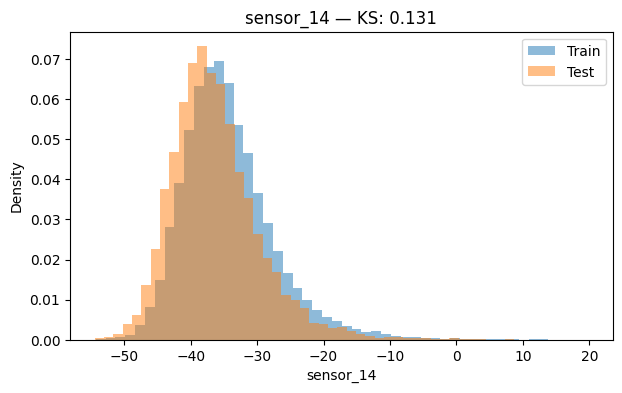

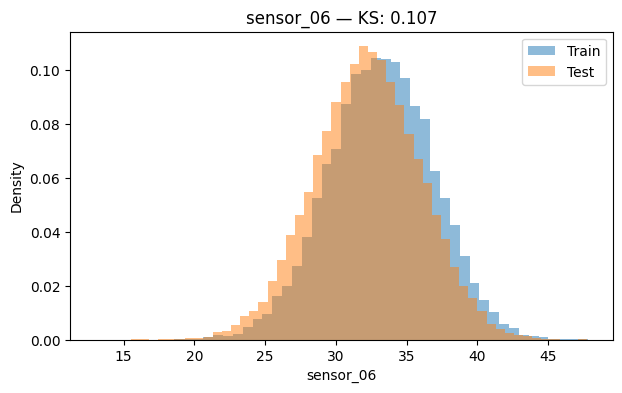

In [71]:
import matplotlib.pyplot as plt

top_shifted = shift_results.head(5)["feature"]

for col in top_shifted:
    plt.figure(figsize=(7, 4))

    plt.hist(
        train[col].dropna(),
        bins=50,
        density=True,
        alpha=0.5,
        label="Train"
    )

    plt.hist(
        test[col].dropna(),
        bins=50,
        density=True,
        alpha=0.5,
        label="Test"
    )

    plt.title(
        f"{col} — KS: "
        f"{shift_results.set_index('feature').loc[col, 'ks_stat']:.3f}"
    )
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

#ML Model

In [67]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_log_error
from catboost import CatBoostRegressor


# ------------------------------------------
# Cross-validation definition
# ------------------------------------------
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# One prediction slot for every training row
oof_pred_log = np.zeros(len(X_raw))

fold_scores = []
best_iterations = []


# ------------------------------------------
# Cross-validation loop
# ------------------------------------------
for fold, (train_idx, valid_idx) in enumerate(
    cv.split(X_raw),
    start=1
):
    print(f"\n========== Fold {fold} ==========")

    # Raw fold data
    X_train_fold_raw = X_raw.iloc[train_idx].copy()
    X_valid_fold_raw = X_raw.iloc[valid_idx].copy()

    y_train_fold = y_log.iloc[train_idx]
    y_valid_fold = y_log.iloc[valid_idx]

    # --------------------------------------
    # Preprocessing learned inside this fold
    # --------------------------------------
    X_train_fold, X_valid_fold, fold_medians = (
        preprocess_fold(
            X_train_fold_raw,
            X_valid_fold_raw
        )
    )

    # --------------------------------------
    # Controlled feature engineering
    # --------------------------------------
    X_train_fold = add_engineered_features(
        X_train_fold
    )

    X_valid_fold = add_engineered_features(
        X_valid_fold
    )

    # Confirm columns match
    assert list(X_train_fold.columns) == list(
        X_valid_fold.columns
    )

    # Confirm no missing values remain
    assert X_train_fold.isna().sum().sum() == 0
    assert X_valid_fold.isna().sum().sum() == 0

    # --------------------------------------
    # Train model
    # --------------------------------------
    model = create_model()

    model.fit(
        X_train_fold,
        y_train_fold,
        eval_set=(X_valid_fold, y_valid_fold),
        use_best_model=True,
        verbose=False
    )

    # Predict log target for untouched fold
    fold_pred_log = model.predict(X_valid_fold)

    # Save predictions in their original rows
    oof_pred_log[valid_idx] = fold_pred_log

    # --------------------------------------
    # Evaluate this fold
    # --------------------------------------
    fold_actual = np.expm1(y_valid_fold)

    fold_predictions = np.clip(
        np.expm1(fold_pred_log),
        0,
        None
    )

    fold_rmsle = np.sqrt(
        mean_squared_log_error(
            fold_actual,
            fold_predictions
        )
    )

    fold_scores.append(fold_rmsle)

    if model.get_best_iteration() is not None:
        best_iterations.append(
            model.get_best_iteration()
        )

    print("Fold RMSLE:", fold_rmsle)


========== Fold 1 ==========
Fold RMSLE: 0.19502723524342727

========== Fold 2 ==========
Fold RMSLE: 0.1894122967403531

========== Fold 3 ==========
Fold RMSLE: 0.18847707095194594

========== Fold 4 ==========
Fold RMSLE: 0.1882755955298898

========== Fold 5 ==========
Fold RMSLE: 0.19225055004149125


In [42]:
oof_predictions = np.clip(
    np.expm1(oof_pred_log),
    0,
    None
)

overall_oof_rmsle = np.sqrt(
    mean_squared_log_error(
        y_raw,
        oof_predictions
    )
)

print("\n==============================")
print("Fold scores:", fold_scores)
print("Mean fold RMSLE:", np.mean(fold_scores))
print("Fold RMSLE std:", np.std(fold_scores))
print("Global OOF RMSLE:", overall_oof_rmsle)
print("==============================")


Fold scores: [np.float64(0.19502723524342727), np.float64(0.1894122967403531), np.float64(0.18847707095194594), np.float64(0.1882755955298898), np.float64(0.19225055004149125)]
Mean fold RMSLE: 0.19068854970142146
Fold RMSLE std: 0.0025925217456645605
Global OOF RMSLE: 0.1907061723076451


In [ ]:
print("Best iterations:", best_iterations)
print("Average best iteration:", np.mean(best_iterations))
print("Median best iteration:", np.median(best_iterations))

Best iterations: [1999, 1462, 1682, 1810, 1998]
Average best iteration: 1790.2
Median best iteration: 1810.0


In [ ]:
final_iterations = int(np.median(best_iterations)) + 1
print("Final iterations:", final_iterations)

Final iterations: 1811


#expermint

In [72]:
analysis = pd.DataFrame({
    "actual_edi": train["edi"],
    "predicted_edi": oof_predictions,
    "core_temp": train["core_temp"]
})

analysis["temperature_group"] = pd.qcut(
    analysis["core_temp"],
    q=5,
    labels=[
        "very low",
        "low",
        "medium",
        "high",
        "very high"
    ]
)

for group, group_data in analysis.groupby(
    "temperature_group",
    observed=True
):
    score = np.sqrt(
        mean_squared_log_error(
            group_data["actual_edi"],
            group_data["predicted_edi"]
        )
    )

    print(group, "RMSLE:", score)

very low RMSLE: 0.14263172289500584
low RMSLE: 0.1599413048246653
medium RMSLE: 0.17305764424877365
high RMSLE: 0.1995762807428832
very high RMSLE: 0.25717610959817916


In [73]:
analysis["prediction_ratio"] = (
    analysis["predicted_edi"] / analysis["actual_edi"]
)

temperature_summary = (
    analysis
    .groupby("temperature_group", observed=True)
    .agg(
        rows=("actual_edi", "size"),
        mean_actual=("actual_edi", "mean"),
        mean_prediction=("predicted_edi", "mean"),
        median_actual=("actual_edi", "median"),
        median_prediction=("predicted_edi", "median"),
        mean_prediction_ratio=("prediction_ratio", "mean"),
        median_prediction_ratio=("prediction_ratio", "median")
    )
)

print(temperature_summary)

                   rows  mean_actual  mean_prediction  median_actual  \
temperature_group                                                      
very low           4800    50.394155        49.615586       32.19415   
low                4800    52.859633        52.313103       34.09165   
medium             4800    59.516515        58.705924       40.18920   
high               4800    77.710265        76.025129       56.83315   
very high          4800   156.760822       152.629234      122.98480   

                   median_prediction  mean_prediction_ratio  \
temperature_group                                             
very low                   32.051558               1.011157   
low                        34.185517               1.019100   
medium                     39.544214               1.015428   
high                       55.320474               1.020255   
very high                 118.942125               1.032228   

                   median_prediction_ratio  
temperat

In [74]:
hot_rows = analysis[
    analysis["temperature_group"] == "very high"
].copy()

hot_rows["edi_group"] = pd.qcut(
    hot_rows["actual_edi"],
    q=4,
    labels=[
        "low EDI",
        "medium-low EDI",
        "medium-high EDI",
        "high EDI"
    ]
)

for group, group_data in hot_rows.groupby(
    "edi_group",
    observed=True
):
    score = np.sqrt(
        mean_squared_log_error(
            group_data["actual_edi"],
            group_data["predicted_edi"]
        )
    )

    median_ratio = (
        group_data["predicted_edi"]
        / group_data["actual_edi"]
    ).median()

    print(f"\n{group}")
    print("Rows:", len(group_data))
    print("RMSLE:", score)
    print("Median prediction ratio:", median_ratio)


low EDI
Rows: 1200
RMSLE: 0.3235847324071809
Median prediction ratio: 1.1088800788434743

medium-low EDI
Rows: 1200
RMSLE: 0.25023950391455946
Median prediction ratio: 0.9810261129589504

medium-high EDI
Rows: 1200
RMSLE: 0.22963673716402874
Median prediction ratio: 0.9452779306951311

high EDI
Rows: 1200
RMSLE: 0.210946168418499
Median prediction ratio: 0.9361987394248408


In [75]:
hot_rows_with_features = X_raw.loc[hot_rows.index].copy()
hot_rows_with_features["edi"] = hot_rows["actual_edi"]

low_hot = hot_rows_with_features[
    hot_rows_with_features["edi"]
    <= hot_rows_with_features["edi"].quantile(0.25)
]

high_hot = hot_rows_with_features[
    hot_rows_with_features["edi"]
    >= hot_rows_with_features["edi"].quantile(0.75)
]

comparison = pd.DataFrame({
    "low_edi_hot_median": low_hot.median(numeric_only=True),
    "high_edi_hot_median": high_hot.median(numeric_only=True)
})

comparison["difference"] = (
    comparison["high_edi_hot_median"]
    - comparison["low_edi_hot_median"]
)

comparison["relative_difference_%"] = (
    comparison["difference"]
    / comparison["low_edi_hot_median"].abs().replace(0, np.nan)
    * 100
)

comparison = comparison.drop(index="edi", errors="ignore")

print(
    comparison
    .sort_values(
        "relative_difference_%",
        key=lambda x: x.abs(),
        ascending=False
    )
    .head(15)
)

                     low_edi_hot_median  high_edi_hot_median   difference  \
sensor_08                      3.027280            18.494320    15.467040   
sensor_16                     -0.009745             0.035710     0.045455   
sensor_18                      0.012495            -0.042310    -0.054805   
sensor_10                     27.748750           128.374975   100.626225   
sensor_13                      1.431135            -3.372415    -4.803550   
sensor_01                      9.518885            36.600060    27.081175   
sensor_27                   1245.384635          4718.969000  3473.584365   
sensor_05                     37.947515           121.831340    83.883825   
asset_age                      5.972815            16.201290    10.228475   
sensor_21                      0.040605            -0.022635    -0.063240   
sensor_03                     51.132840           -25.737135   -76.869975   
hours_since_service          286.878260           690.380090   403.501830   

Write this in your experiment notes:

The train–test shift is concentrated partly in temperature-related features. The model’s OOF error rises sharply with temperature, but the failure is not a simple prediction bias. Within hot machines, low EDI is overpredicted and high EDI is underpredicted. Age, service history, and several sensor features strongly separate these groups. Therefore, future validation should include a test-like difficult holdout, and future feature work should focus on interactions and operating conditions rather than global temperature correction.

#submision

In [48]:
# Start from the original raw data
X_full_raw = train.drop(columns=["id", "edi"]).copy()
X_test_raw = test.drop(columns=["id"]).copy()

y_full_log = np.log1p(train["edi"])
test_ids = test["id"].copy()

# Apply the same missing-value preprocessing used in cross-validation
X_full, X_test_final, full_medians = preprocess_fold(
    X_full_raw,
    X_test_raw
)

# Add the same engineered features used in cross-validation
X_full = add_engineered_features(X_full)
X_test_final = add_engineered_features(X_test_final)

# Safety checks
print("X_full shape:", X_full.shape)
print("X_test_final shape:", X_test_final.shape)
print("Remaining missing values in train:", X_full.isna().sum().sum())
print("Remaining missing values in test:", X_test_final.isna().sum().sum())

assert list(X_full.columns) == list(X_test_final.columns)
assert X_full.isna().sum().sum() == 0
assert X_test_final.isna().sum().sum() == 0

X_full shape: (24000, 51)
X_test_final shape: (16000, 51)
Remaining missing values in train: 0
Remaining missing values in test: 0


In [49]:
from catboost import CatBoostRegressor

final_model = CatBoostRegressor(
    iterations=1811,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=3.0,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

final_model.fit(
    X_full,
    y_full_log,
    verbose=False
)

test_pred_log = final_model.predict(X_test_final)
test_predictions = np.clip(np.expm1(test_pred_log), 0, None)

submission = pd.DataFrame({
    "id": test_ids,
    "edi": test_predictions
})

submission.to_csv("catboost_clean_1811.csv", index=False)

print(submission.head())
print("Submission shape:", submission.shape)
print("Missing values:", submission.isna().sum().sum())

      id        edi
0  24000  46.454032
1  24001  36.287957
2  24002  52.058319
3  24003  83.807648
4  24004  31.019245
Submission shape: (16000, 2)
Missing values: 0
